In [ ]:
import pandas as pd

df = pd.read_csv("/content/space_weather_unified.csv")

df.head()


,event_id,event_type,begin_time,peak_time,end_time,class_type,source_location,active_region,instruments,note,kp_index,observed_time,source,date,year,month,day,hour
0,2023-07-11T14:19:00-FLR-001,Solar Flare,2023-07-11 14:19:00+00:00,2023-07-11 14:35:00+00:00,2023-07-11 14:45:00+00:00,M2.0,N25E90,13379.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2023-07-11,2023,7,11,14
1,2023-07-11T16:02:00-FLR-001,Solar Flare,2023-07-11 16:02:00+00:00,2023-07-11 16:12:00+00:00,2023-07-11 16:25:00+00:00,M1.1,N25E89,13372.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2023-07-11,2023,7,11,16
2,2023-07-11T16:25:00-FLR-001,Solar Flare,2023-07-11 16:25:00+00:00,2023-07-11 16:27:00+00:00,2023-07-11 16:30:00+00:00,M1.0,N25E89,13372.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2023-07-11,2023,7,11,16
3,2023-07-11T17:51:00-FLR-001,Solar Flare,2023-07-11 17:51:00+00:00,2023-07-11 18:08:00+00:00,2023-07-11 18:16:00+00:00,M6.8,N25E88,13372.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2023-07-11,2023,7,11,17
4,2023-07-11T19:20:00-FLR-001,Solar Flare,2023-07-11 19:20:00+00:00,2023-07-11 19:29:00+00:00,2023-07-11 19:39:00+00:00,M1.0,N25E88,13372.0,GOES-P: EXIS 1.0-8.0,Simultaneous brightening south of AR3363.,NaN,NaN,NaN,2023-07-11,2023,7,11,19


In [ ]:

# standardize column names
df.columns = df.columns.str.lower()


In [ ]:

# convert datetime columns safely
for col in ["begin_time", "peak_time", "end_time"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [ ]:

# sort by time (important for space physics data)
df = df.sort_values("begin_time")

# fill missing values
df["class_type"] = df["class_type"].fillna("unknown")
df["source_location"] = df["source_location"].fillna("unknown")
df["active_region"] = df["active_region"].fillna(0)
df["kp_index"] = df["kp_index"].fillna(0)


In [ ]:
# remove duplicates
df = df.drop_duplicates()

# final sanity check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1743 entries, 0 to 1742
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   event_id         1743 non-null   object             
 1   event_type       1743 non-null   object             
 2   begin_time       1743 non-null   datetime64[ns, UTC]
 3   peak_time        1599 non-null   datetime64[ns, UTC]
 4   end_time         1599 non-null   datetime64[ns, UTC]
 5   class_type       1743 non-null   object             
 6   source_location  1743 non-null   object             
 7   active_region    1743 non-null   float64            
 8   instruments      1702 non-null   object             
 9   note             398 non-null    object             
 10  kp_index         1743 non-null   float64            
 11  observed_time    41 non-null     object             
 12  source           41 non-null     object             
 13  date             1

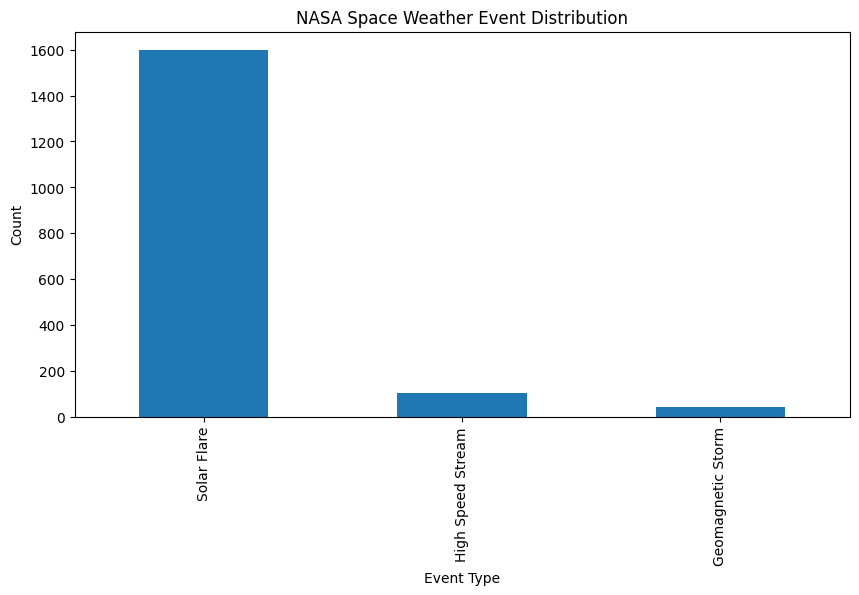

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df["event_type"].value_counts().plot(kind="bar")
plt.title("NASA Space Weather Event Distribution")
plt.ylabel("Count")
plt.xlabel("Event Type")
plt.show()

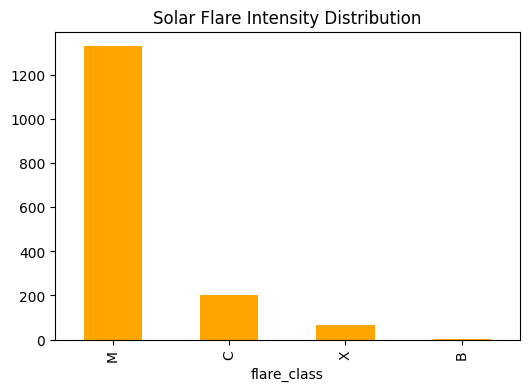

In [ ]:
flares = df[df["event_type"] == "Solar Flare"].copy()

flares["flare_class"] = flares["class_type"].astype(str).str[0]

plt.figure(figsize=(6,4))
flares["flare_class"].value_counts().plot(kind="bar", color="orange")
plt.title("Solar Flare Intensity Distribution")
plt.show()

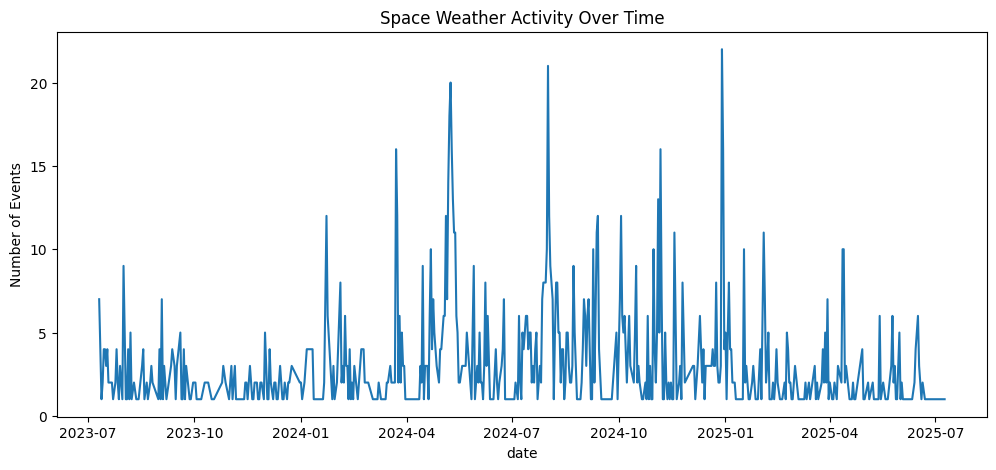

In [ ]:
df["date"] = df["begin_time"].dt.date

daily_counts = df.groupby("date").size()

plt.figure(figsize=(12,5))
daily_counts.plot()
plt.title("Space Weather Activity Over Time")
plt.ylabel("Number of Events")
plt.show()

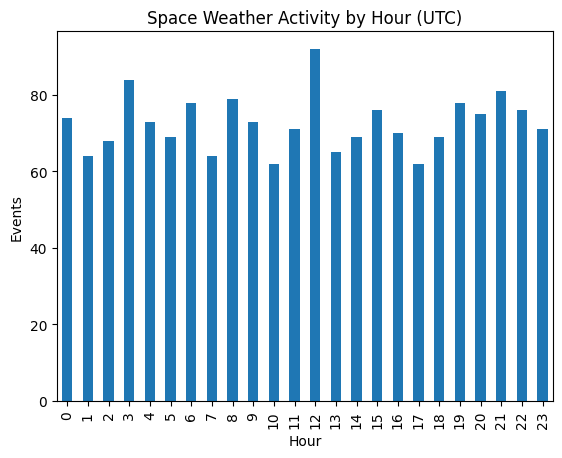

In [ ]:
df["hour"].value_counts().sort_index().plot(kind="bar")
plt.title("Space Weather Activity by Hour (UTC)")
plt.xlabel("Hour")
plt.ylabel("Events")
plt.show()

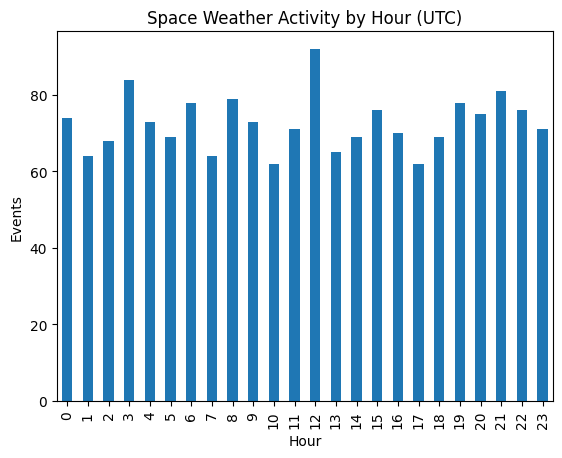

In [ ]:
df["hour"].value_counts().sort_index().plot(kind="bar")
plt.title("Space Weather Activity by Hour (UTC)")
plt.xlabel("Hour")
plt.ylabel("Events")
plt.show()

In [ ]:
def risk_label(row):
    event = str(row["event_type"]).lower()
    cls = str(row["class_type"])

    # HIGH risk (dangerous space weather)
    if "flare" in event and ("x" in cls or "m" in cls):
        return 2
    if "geomagnetic" in event and row["kp_index"] >= 6:
        return 2

    # MEDIUM risk
    if "cme" in event or "high speed" in event:
        return 1

    # LOW risk
    return 0

df["risk"] = df.apply(risk_label, axis=1)

In [ ]:
df["year"] = df["begin_time"].dt.year
df["month"] = df["begin_time"].dt.month
df["day"] = df["begin_time"].dt.day
df["weekday"] = df["begin_time"].dt.weekday
df["hour"] = df["begin_time"].dt.hour

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_event = LabelEncoder()
df["event_type_encoded"] = le_event.fit_transform(df["event_type"])

le_class = LabelEncoder()
df["class_type_encoded"] = le_class.fit_transform(df["class_type"].astype(str))

In [ ]:
df["activity_score"] = df["kp_index"] * (df["hour"] + 1)

In [ ]:
features = [
    "event_type_encoded",
    "class_type_encoded",
    "kp_index",
    "hour",
    "month",
    "weekday",
    "activity_score"
]

X = df[features]
y = df["risk"]

X.head()

,event_type_encoded,class_type_encoded,kp_index,hour,month,weekday,activity_score
0,2,85,0.0,14,7,1,0.0
1,2,76,0.0,16,7,1,0.0
2,2,75,0.0,16,7,1,0.0
3,2,132,0.0,17,7,1,0.0
4,2,75,0.0,19,7,1,0.0


In [ ]:
# rebuild dataset safely
df_model = df.copy()

# ensure clean columns
df_model = df_model.dropna(subset=["event_type", "class_type", "begin_time"])

# time features only
df_model["hour"] = df_model["begin_time"].dt.hour
df_model["month"] = df_model["begin_time"].dt.month
df_model["weekday"] = df_model["begin_time"].dt.weekday
df_model["day"] = df_model["begin_time"].dt.day

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_event = LabelEncoder()
df_model["event_type_encoded"] = le_event.fit_transform(df_model["event_type"])

le_class = LabelEncoder()
df_model["class_type_encoded"] = le_class.fit_transform(df_model["class_type"].astype(str))

In [ ]:
features = [
    "event_type_encoded",
    "class_type_encoded",
    "hour",
    "month",
    "weekday",
    "day"
]

X = df_model[features]
y = df_model["risk"]

In [ ]:
train_mask = df_model["year"] < 2025

X_train = X[train_mask]
X_test = X[~train_mask]

y_train = y[train_mask]
y_test = y[~train_mask]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

print("\nXGboost Report:\n")
print(classification_report(y_test, xgb_pred))

Random Forest Accuracy: 0.9841269841269841
XGBoost Accuracy: 0.9873015873015873

XGboost Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       261
           1       1.00      1.00      1.00        48
           2       0.62      0.83      0.71         6

    accuracy                           0.99       315
   macro avg       0.87      0.94      0.90       315
weighted avg       0.99      0.99      0.99       315



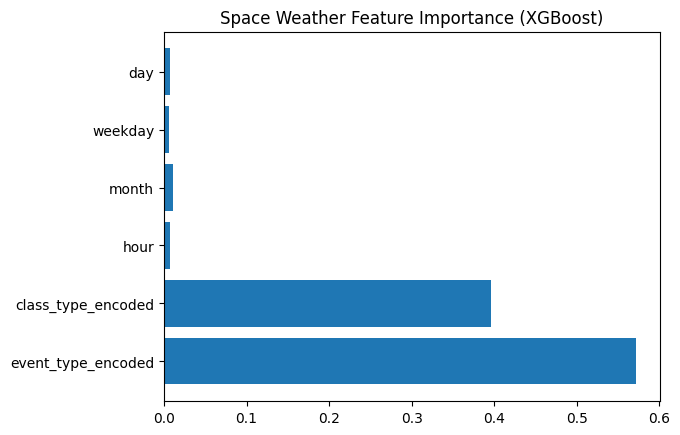

In [ ]:
import matplotlib.pyplot as plt

plt.barh(features, xgb.feature_importances_)
plt.title("Space Weather Feature Importance (XGBoost)")
plt.show()

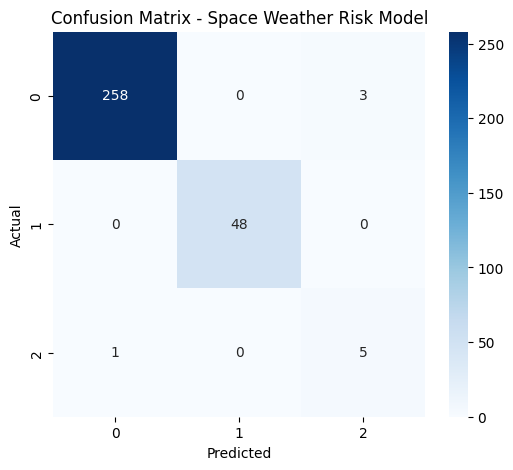

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Space Weather Risk Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
xgb_proba = xgb.predict_proba(X_test)

xgb_proba[:5]

array([[9.9977022e-01, 1.3019281e-04, 9.9637778e-05],
       [5.8284897e-01, 1.6464595e-02, 4.0068644e-01],
       [9.9975878e-01, 1.3229880e-04, 1.0896675e-04],
       [9.9982738e-01, 1.0808525e-04, 6.4522799e-05],
       [9.9982446e-01, 1.0925871e-04, 6.6257766e-05]], dtype=float32)

In [ ]:
import numpy as np

for i in range(5):
    print(f"Sample {i}")
    print("Low / Medium / High Risk Probabilities:")
    print(np.round(xgb_proba[i], 3))
    print("Predicted Class:", xgb_pred[i])
    print("----")

Sample 0
Low / Medium / High Risk Probabilities:
[1. 0. 0.]
Predicted Class: 0
----
Sample 1
Low / Medium / High Risk Probabilities:
[0.583 0.016 0.401]
Predicted Class: 0
----
Sample 2
Low / Medium / High Risk Probabilities:
[1. 0. 0.]
Predicted Class: 0
----
Sample 3
Low / Medium / High Risk Probabilities:
[1. 0. 0.]
Predicted Class: 0
----
Sample 4
Low / Medium / High Risk Probabilities:
[1. 0. 0.]
Predicted Class: 0
----


In [ ]:
def interpret_risk(pred):
    if pred == 2:
        return "HIGH RISK (Extreme solar activity)"
    elif pred == 1:
        return "MODERATE RISK (Elevated activity)"
    else:
        return "LOW RISK (Stable conditions)"

In [ ]:
high_risk_indices = [i for i in range(len(xgb_pred)) if xgb_pred[i] == 2]

for i in high_risk_indices[:10]:
    print("HIGH RISK DETECTED")
    print(interpret_risk(xgb_pred[i]))

HIGH RISK DETECTED
HIGH RISK (Extreme solar activity)
HIGH RISK DETECTED
HIGH RISK (Extreme solar activity)
HIGH RISK DETECTED
HIGH RISK (Extreme solar activity)
HIGH RISK DETECTED
HIGH RISK (Extreme solar activity)
HIGH RISK DETECTED
HIGH RISK (Extreme solar activity)
HIGH RISK DETECTED
HIGH RISK (Extreme solar activity)
HIGH RISK DETECTED
HIGH RISK (Extreme solar activity)
HIGH RISK DETECTED
HIGH RISK (Extreme solar activity)


In [ ]:
def interpret_prob(prob):
    low, med, high = prob

    if high > 0.6:
        return " HIGH RISK (Strong solar disturbance likely)"
    elif med > 0.5:
        return " MODERATE RISK (Possible disturbance)"
    else:
        return " LOW RISK (Stable conditions)"

In [ ]:
def interpret_risk(pred):
    if pred == 2:
        return "HIGH SPACE WEATHER RISK (Satellite disruption possible)"
    elif pred == 1:
        return "MODERATE ACTIVITY (Minor impact possible)"
    else:
        return "LOW RISK (Stable conditions)"

# test on predictions
for i in range(5):
    print(interpret_risk(xgb_pred[i]))

LOW RISK (Stable conditions)
LOW RISK (Stable conditions)
LOW RISK (Stable conditions)
LOW RISK (Stable conditions)
LOW RISK (Stable conditions)


In [ ]:
def uncertainty(prob):
    return 1 - max(prob)

In [ ]:
print("High risk distribution:")
print((xgb_pred == 2).mean())

High risk distribution:
0.025396825396825397


In [ ]:
for i in range(len(xgb_pred)):
    if xgb_proba[i][2] > 0.6:
        print("HIGH RISK SCENARIO")
        print(xgb_proba[i])

HIGH RISK SCENARIO
[0.17773734 0.01309682 0.8091659 ]
HIGH RISK SCENARIO
[0.11045323 0.00751856 0.8820282 ]
HIGH RISK SCENARIO
[0.07501776 0.00685251 0.91812974]
HIGH RISK SCENARIO
[0.10021918 0.00863328 0.89114755]
HIGH RISK SCENARIO
[0.01696208 0.00272704 0.98031086]
HIGH RISK SCENARIO
[0.07194825 0.00685506 0.9211967 ]
HIGH RISK SCENARIO
[0.015784   0.00267764 0.9815384 ]


In [ ]:
print("Actual high risk ratio:", (y_test == 2).mean())
print("Predicted high risk ratio:", (xgb_pred == 2).mean())

Actual high risk ratio: 0.01904761904761905
Predicted high risk ratio: 0.025396825396825397


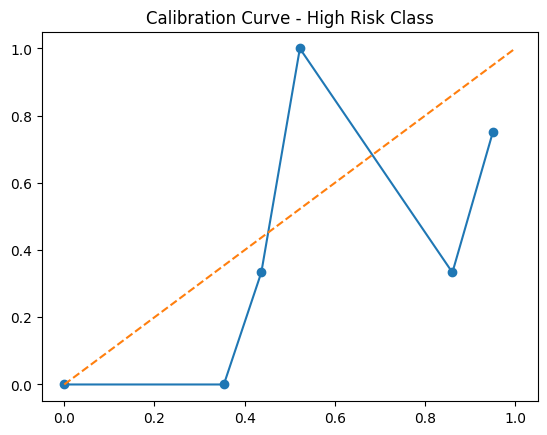

In [ ]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob = xgb.predict_proba(X_test)[:, 2]

frac_pos, mean_pred = calibration_curve(y_test == 2, prob, n_bins=10)

plt.plot(mean_pred, frac_pos, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.title("Calibration Curve - High Risk Class")
plt.show()

In [ ]:
def risk_policy(prob):
    low, med, high = prob

    if high > 0.7:
        return "ALERT: Extreme space weather warning"
    elif high > 0.4:
        return "Watch: Elevated solar activity"
    else:
        return "Normal space weather conditions"

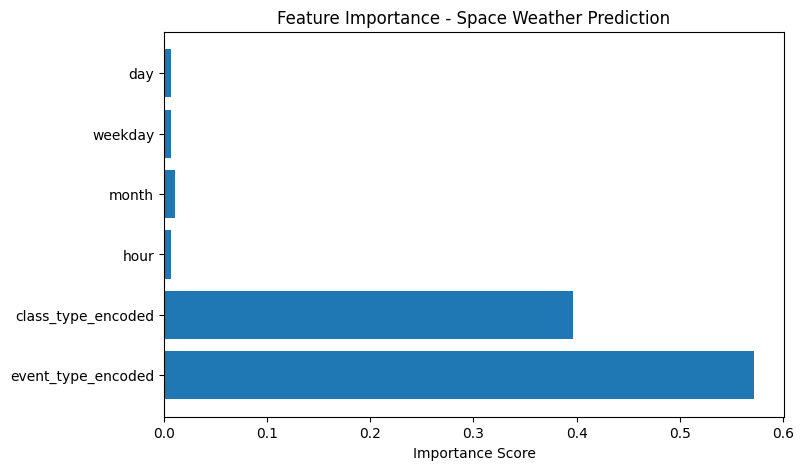

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(features, xgb.feature_importances_)
plt.title("Feature Importance - Space Weather Prediction")
plt.xlabel("Importance Score")
plt.show()

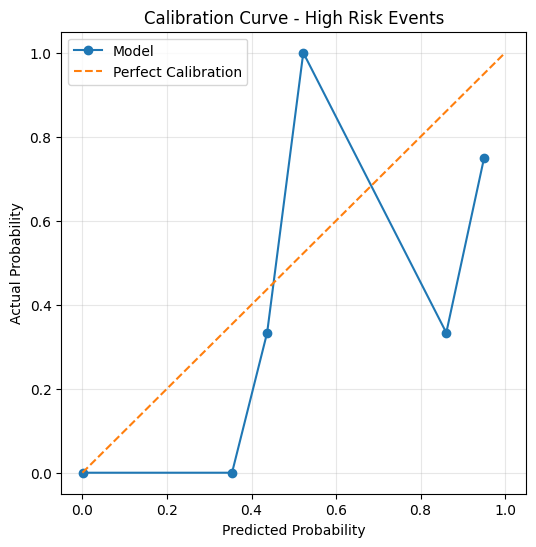

In [ ]:
plt.figure(figsize=(6,6))

plt.plot(mean_pred, frac_pos, marker='o', label="Model")
plt.plot([0,1], [0,1], linestyle='--', label="Perfect Calibration")

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve - High Risk Events")
plt.legend()

plt.grid(alpha=0.3)
plt.show()

The calibration curve deviates from the ideal diagonal,
indicating that predicted probabilities are not perfectly aligned
with observed event frequencies.

The model shows overconfidence in certain probability ranges,
a known characteristic of ensemble boosting methods.

Despite this, relative ranking of risk remains strong,
making the model suitable for decision-support systems
rather than precise probability estimation.